In [6]:
import re
import time
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)


In [7]:
# 1. Load Data

df = pd.read_csv("/content/marketing_sample_for_naukri_com-jobs__20190701_20190830__30k_data.csv")
print("Shape:", df.shape)
df.head(3)


Shape: (30000, 11)


,Uniq Id,Crawl Timestamp,Job Title,Job Salary,Job Experience Required,Key Skills,Role Category,Location,Functional Area,Industry,Role
0,9be62c49a0b7ebe982a4af1edaa7bc5f,2019-07-05 01:46:07 +0000,Digital Media Planner,Not Disclosed by Recruiter,5 - 10 yrs,Media Planning| Digital Media,Advertising,Mumbai,"Marketing , Advertising , MR , PR , Media Plan...","Advertising, PR, MR, Event Management",Media Planning Executive/Manager
1,3c52d436e39f596b22519da2612f6a56,2019-07-06 08:04:50 +0000,Online Bidding Executive,Not Disclosed by Recruiter,2 - 5 yrs,pre sales| closing| software knowledge| clien...,Retail Sales,"Pune,Pune","Sales , Retail , Business Development","IT-Software, Software Services",Sales Executive/Officer
2,ffad8a2396c60be2bf6d0e2ff47c58d4,2019-08-05 15:50:44 +0000,Trainee Research/ Research Executive- Hi- Tec...,Not Disclosed by Recruiter,0 - 1 yrs,Computer science| Fabrication| Quality check|...,R&D,Gurgaon,"Engineering Design , R&D","Recruitment, Staffing",R&D Executive


In [8]:
# 2. Drop Duplicates

df.duplicated().sum()
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

In [9]:
# 3. Drop Missing Target / Feature Rows

df = df.dropna(subset=["Role Category", "Job Title", "Key Skills"])

In [10]:
# Keep only the top 15 most frequent Role Categories (rest are too rare to model)
top_categories = df["Role Category"].value_counts().head(15).index
df = df[df["Role Category"].isin(top_categories)].copy()
print("Shape after filtering to top 15 categories:", df.shape)



Shape after filtering to top 15 categories: (20973, 11)


In [11]:
# 4. Clean Text

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z\s|]", " ", text)     # keep only letters, spaces, pipes
    text = re.sub(r"\s+", " ", text).strip()   # collapse whitespace
    return text

df["combined_text"] = (
    df["Job Title"].fillna("") + " " +
    df["Key Skills"].fillna("") + " " +
    df["Location"].fillna("")
)
df["clean_text"] = df["combined_text"].apply(clean_text)



In [12]:
# 5. Encode Labels

label_encoder = LabelEncoder()
df["label"] = label_encoder.fit_transform(df["Role Category"])


In [13]:
# 6. Train / Test Split

X_train_text, X_test_text, y_train, y_test = train_test_split(
    df["clean_text"], df["label"], test_size=0.2, random_state=42, stratify=df["label"]
)



In [14]:
# 7. TF-IDF Vectorization

vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_vec = vectorizer.fit_transform(X_train_text)
X_test_vec = vectorizer.transform(X_test_text)




In [15]:
# 8. Train Logistic Regression

start = time.time()

clf = LogisticRegression(max_iter=1000, class_weight="balanced")
clf.fit(X_train_vec, y_train)

print(f"Training time: {time.time() - start:.2f}s")



Training time: 5.98s


                                            precision    recall  f1-score   support

                                  Accounts       0.79      0.92      0.85       172
Admin/Maintenance/Security/Datawarehousing       0.46      0.75      0.57       182
                           Corporate Sales       0.35      0.53      0.42       139
                                  Creative       0.56      0.91      0.70        78
                        Engineering Design       0.61      0.75      0.67        71
                      HR/ Recruitment / IR       0.82      0.85      0.83       220
                                 Marketing       0.53      0.77      0.63        93
                      Medical Professional       0.78      0.84      0.81        82
                                     Other       0.46      0.39      0.42       170
      Production/Manufacturing/Maintenance       0.67      0.82      0.74       114
                      Programming & Design       0.94      0.78      0.85  

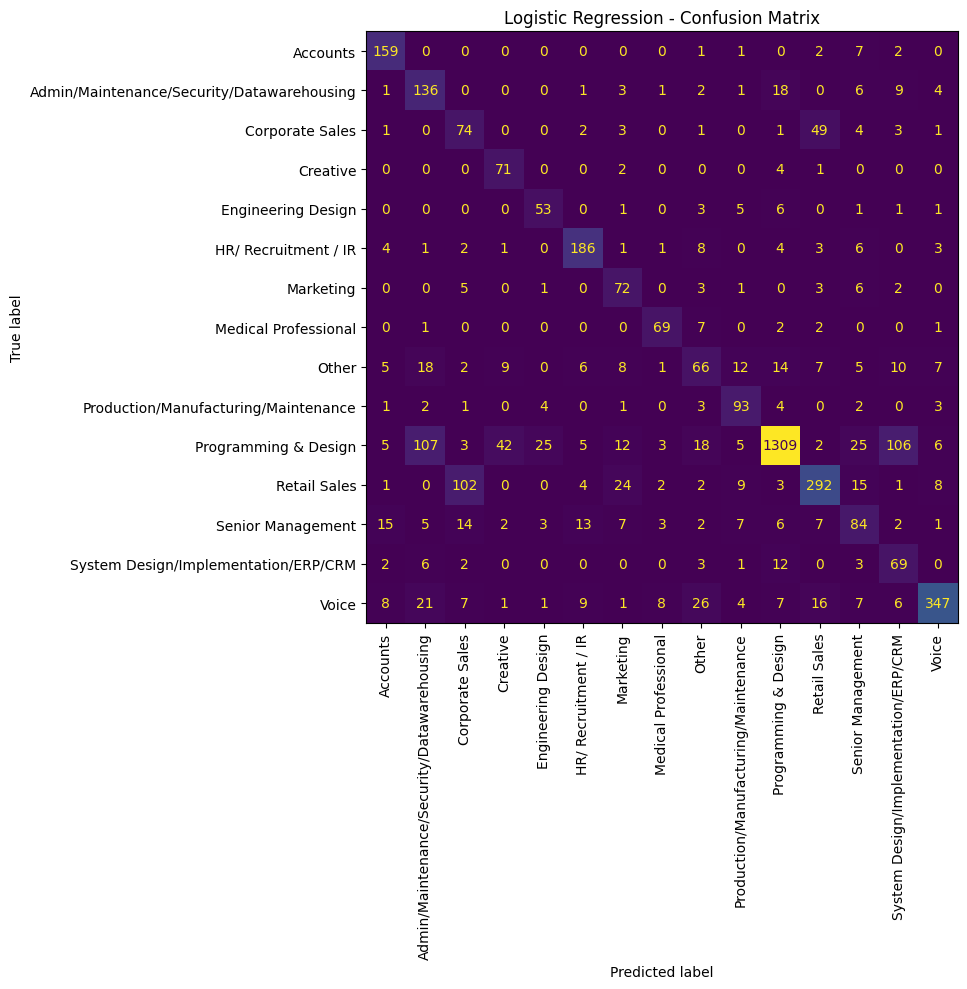

In [16]:
# 9. Evaluate

y_pred = clf.predict(X_test_vec)

print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))
print("Accuracy:", accuracy_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(ax=ax, xticks_rotation=90, colorbar=False)
plt.title("Logistic Regression - Confusion Matrix")
plt.tight_layout()
plt.savefig("logreg_confusion_matrix.png")
plt.show()



In [17]:

# 10. Save Artifacts

with open("role_classifier.pkl", "wb") as f:
    pickle.dump(clf, f)

with open("tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(vectorizer, f)

with open("label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder, f)

print("Saved: role_classifier.pkl, tfidf_vectorizer.pkl, label_encoder.pkl")

Saved: role_classifier.pkl, tfidf_vectorizer.pkl, label_encoder.pkl
